# **Demographic and Personal Characteristics:**

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as ex

In [4]:
data= pd.read_csv('data.csv')   

In [6]:
data.shape

(42468, 14)

### **1. Age Distribution by Race:**

In [9]:
data['age'].describe()

count    42468.000000
mean        39.476947
std         13.779595
min         17.000000
25%         29.000000
50%         38.000000
75%         49.000000
max         90.000000
Name: age, dtype: float64

* **mean** (`39.48`): The average age is about 39.5 years.
* **std** (`13.78`): The standard deviation is 13.78 (under normality), indicating moderate spread around the mean. So, 68% of people fall within ±1 std of the mean age ie. have age between ~25.7 and ~53.3 years (39.48 ± 13.78). And, 95% fall within ±2 std ie. have ages between ~11.9 and ~67.1 years. 

* **min** (`17.0`): The youngest person in the dataset is 17 years old.
* **25%** (`29.0`): 25% of the people are younger than or equal to 29.
* **50%** (`38.0`): The median age is 38, meaning half are younger and half are older than 38.
* **75%** (`49.0`): 75% of the people are younger than or equal to 49.
* **max** (`90.0`): The oldest person in the dataset is 90 years old.


In [10]:
data['race'].unique()

array(['Black', 'White', 'Asian-Pac-Islander', 'Other',
       'Amer-Indian-Eskimo'], dtype=object)

In [52]:
data["race"].value_counts()

race
White                 35541
Black                  4536
Asian-Pac-Islander     1515
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64

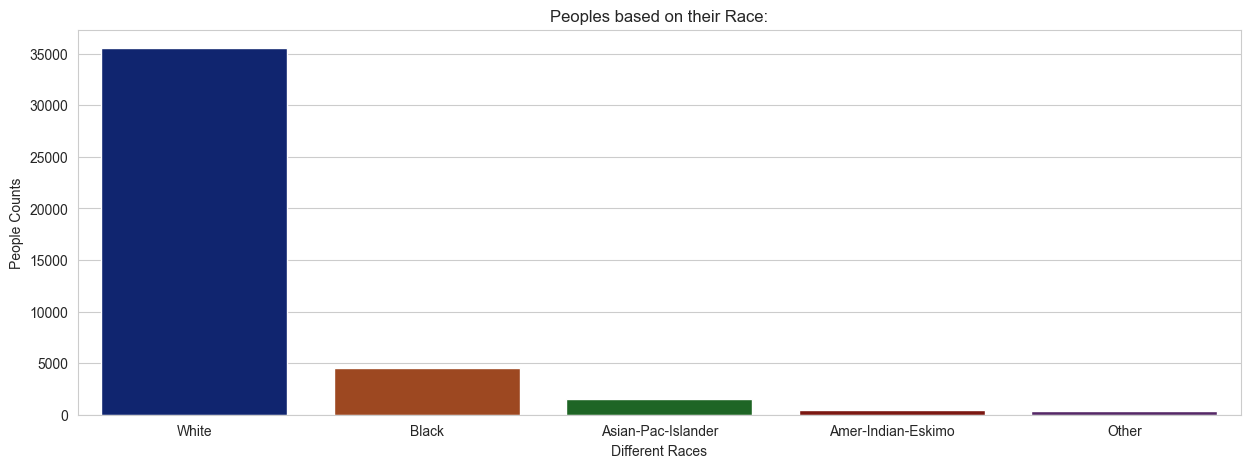

In [58]:
# Supress warnings if they occur: 
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(15, 5))
sns.barplot(x= data["race"].value_counts().index, y= data["race"].value_counts().values, palette= "dark")
plt.title("Peoples based on their Race:")
plt.xlabel("Different Races")
plt.ylabel("People Counts")
plt.show()

The chart shows that the majority of people identified as White, with significantly fewer people identified as Black, Asian/Pacific Islander, American Indian/Eskimo, and Other.

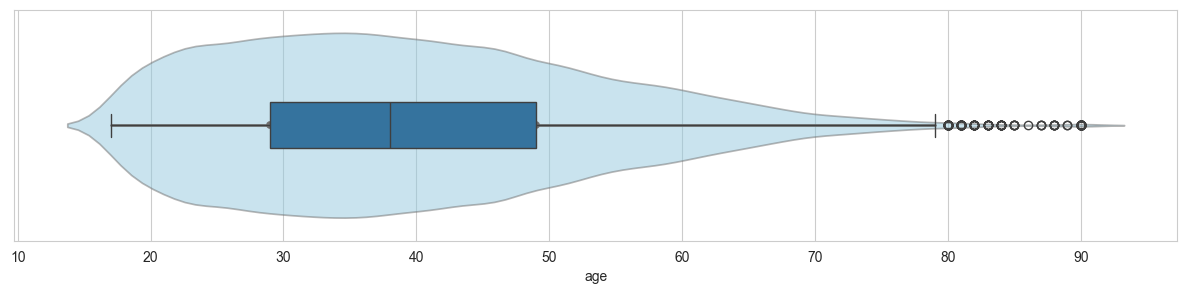

In [47]:
sns.set_style('whitegrid')
plt.figure(figsize=(15, 3))
ax = sns.violinplot(data=data, x="age", color="skyblue", alpha=0.5)
sns.boxplot(data=data, x="age", width=0.2, saturation=0.7, ax=ax, boxprops={'zorder': 2})
plt.show()

- **Median age** is around **38**, shown by the central line in the box.

- **Interquartile range (IQR)** (middle 50%) spans roughly **29 to 49 years**.

- **Most common ages** are in the **late 20s to late 40s**, as the violin is widest there — indicating higher density.

- **Distribution tails off** after age 50 and narrows significantly beyond 70.

- **Outliers** (individual dots) appear above **\~80**, indicating fewer but valid older age entries.

- **Age distribution is slightly left-skewed** — more people are younger than the mean, with a tail toward older ages.

In [70]:
data.groupby(by= "race")["age"]

In [67]:
agr= data.groupby('race')['age'].describe()
agr

,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
Amer-Indian-Eskimo,470.0,36.693617,12.155871,17.0,28.0,35.0,44.0,82.0
Asian-Pac-Islander,1515.0,37.858086,12.778793,17.0,28.0,36.0,45.0,90.0
Black,4536.0,38.161155,12.914862,17.0,28.0,37.0,47.0,90.0
Other,406.0,33.657635,11.736764,17.0,25.0,31.0,41.0,77.0
White,35541.0,39.817169,13.935150,17.0,29.0,38.0,49.0,90.0


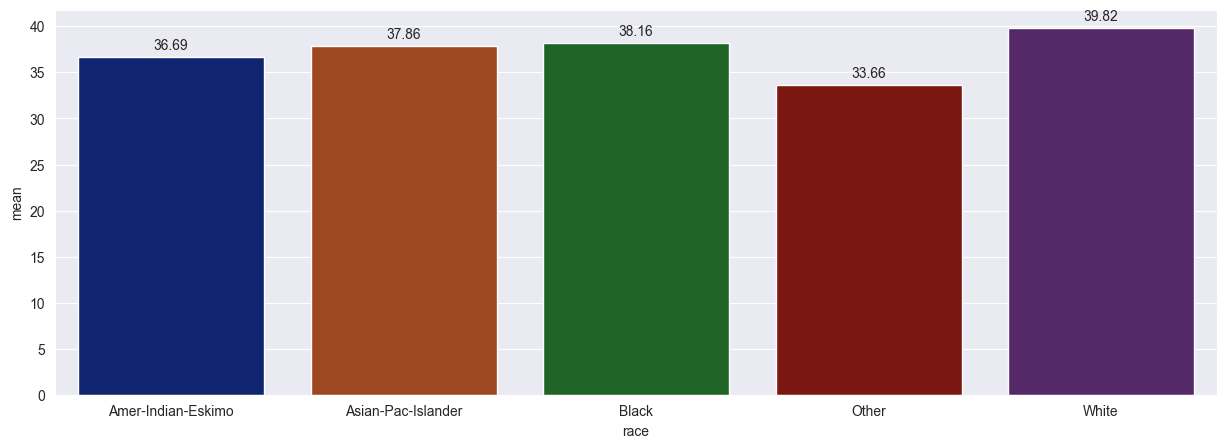

In [72]:
plt.figure(figsize=(15, 5))
# mean age by race: 
sns.set_style('darkgrid')
sns.barplot(data= agr, x= agr.index, y= 'mean', palette= 'dark')
# add annotations: 
for i, v in enumerate(agr['mean']):
    plt.text(x= i, y= v + 0.5, s= str(round(v, 2)), ha='center', va='bottom')

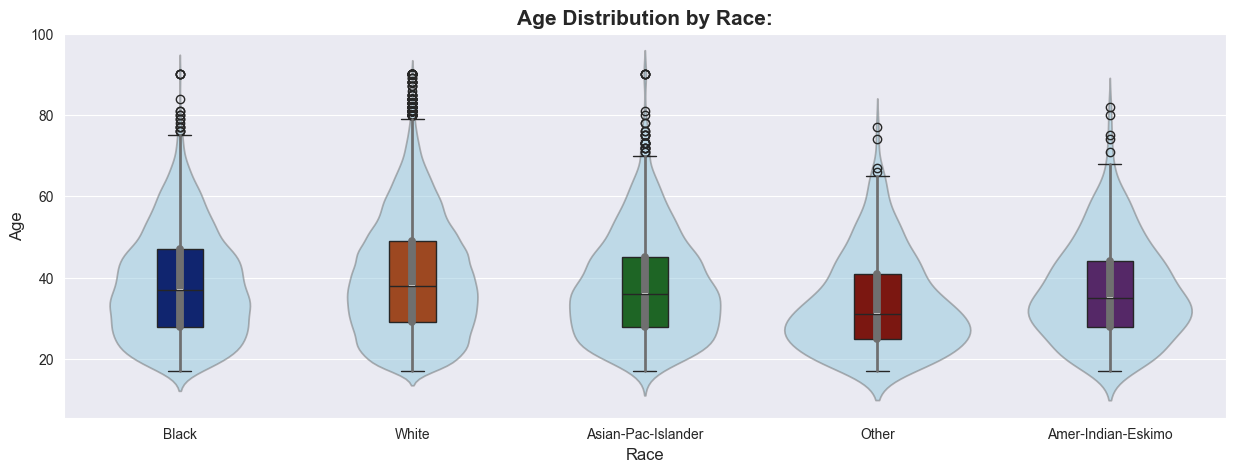

In [89]:
plt.figure(figsize=(15, 5))
sns.set_style('darkgrid')
sns.boxplot(data= data, x= "race", y= "age", palette= 'dark', width= 0.2)
sns.violinplot(data= data, x= "race", y= "age", color= 'skyblue', alpha= 0.5)
plt.title("Age Distribution by Race:", fontsize= 15, fontweight= 'bold')
plt.xlabel("Race", fontsize= 12)
plt.ylabel("Age", fontsize= 12)
plt.show()

The chart displays the age distribution across different races.
- **Black**: Wider age range with some older individuals.
- **White**: Similar distribution but with a longer tail of older ages.
- **Asian/Pacific Islander**: Concentrated around middle ages.
- **Other**: Similar to Black, with a varied age distribution.
- **American Indian/Eskimo**: More limited age range, generally younger.

---
---
---

### **2. Distribution of Age:**

In [90]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [91]:
data["age"].nunique()

74

In [92]:
data["age"].unique()

array([25, 38, 28, 44, 18, 34, 29, 63, 24, 55, 65, 36, 26, 58, 48, 43, 20,
       37, 40, 72, 45, 22, 23, 54, 32, 46, 56, 17, 39, 52, 21, 42, 33, 30,
       47, 41, 19, 69, 50, 31, 59, 49, 51, 27, 57, 61, 64, 79, 73, 53, 77,
       80, 62, 35, 68, 66, 75, 60, 67, 71, 70, 90, 81, 74, 78, 82, 83, 85,
       76, 84, 89, 88, 87, 86])

In [99]:
data["age"].value_counts().sort_values(ascending= False)

age
33    1178
36    1158
31    1155
35    1146
34    1139
      ... 
88       6
85       5
87       3
89       2
86       1
Name: count, Length: 74, dtype: int64

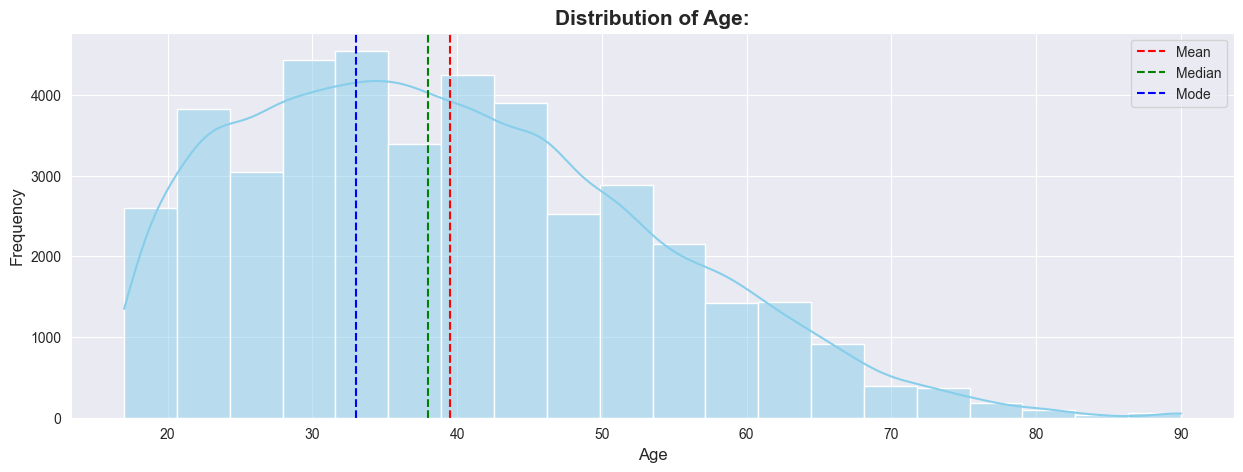

In [108]:
plt.figure(figsize=(15, 5) )
sns.set_style('darkgrid')
sns.histplot(data["age"], bins= 20, kde= True, color= 'skyblue')
plt.title("Distribution of Age:", fontsize= 15, fontweight= 'bold') 
plt.xlabel("Age", fontsize= 12)
plt.ylabel("Frequency", fontsize= 12)
# plot mean, median and mode:
plt.axvline(x= data["age"].mean(), color= 'red', linestyle= '--', label= 'Mean')
plt.axvline(x= data["age"].median(), color= 'green', linestyle= '--', label= 'Median')
plt.axvline(x= data["age"].mode()[0], color= 'blue', linestyle= '--', label= 'Mode')
plt.legend()
plt.show()

- The **histogram** shows frequency across age groups, peaking in the middle 30s.

- The **red line** indicates the **mean** age, while the **green line** shows the **median** age, both around 40.

- The **blue dashed line** represents the **mode**, indicating the most common age.

Overall, the distribution is positively skewed, with more younger individuals and a gradual decline in frequency as age increases.

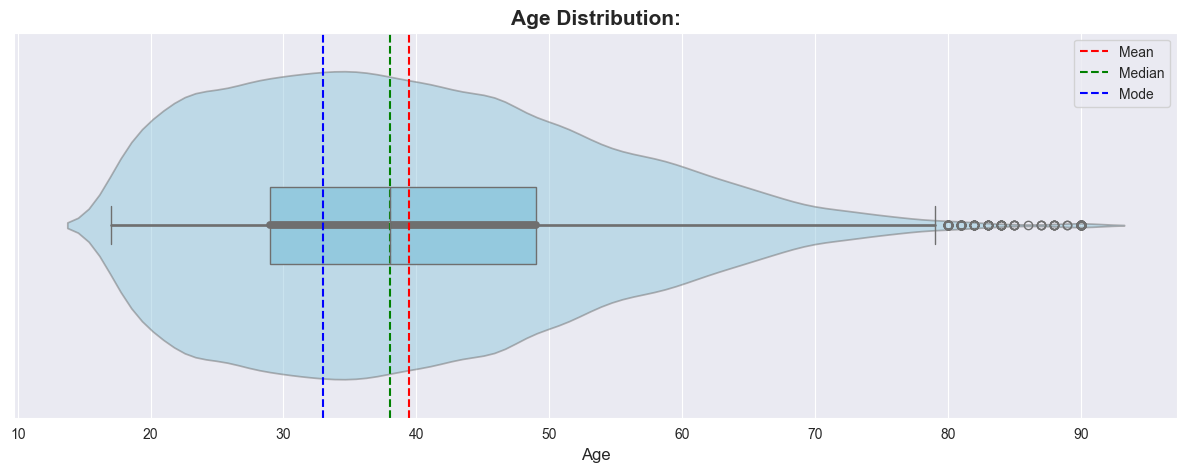

In [114]:
plt.figure(figsize=(15, 5))
sns.boxplot(x= data["age"], color= 'skyblue', width= 0.2)
sns.violinplot(x= data["age"], color= 'skyblue', alpha= 0.5)
plt.title("Age Distribution:", fontsize= 15, fontweight= 'bold')    
plt.xlabel("Age", fontsize= 12)
# add vertical lines for mean, median and mode:
plt.axvline(x= data["age"].mean(), color= 'red', linestyle= '--', label= 'Mean')
plt.axvline(x= data["age"].median(), color= 'green', linestyle= '--', label= 'Median')
plt.axvline(x= data["age"].mode()[0], color= 'blue', linestyle= '--', label= 'Mode')
plt.legend()
plt.show()

----
---
----

### **3. Age Distribution by Salary Class:**

In [115]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

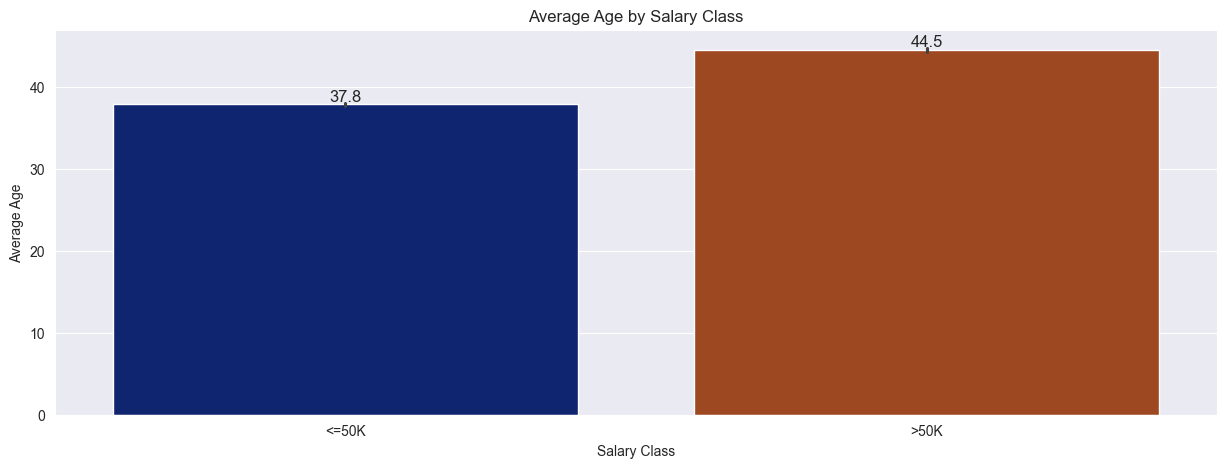

In [123]:
plt.figure(figsize=(15, 5))
ax = sns.barplot(data=data, x="salary", y="age", palette="dark", hue="salary", legend=False)

# Add numbers on each bar
for p in ax.patches: # `ax.patches` is a list of all rectangle objects (bars) in the plot.

    # Gets the height of each bar, which corresponds to the y-value (average age in this case).
    height = p.get_height() 

    ax.annotate(f'{height:.1f}',  # Formats the height to one decimal place
                # p.get_x() + p.get_width()/2: Places the label at the horizontal center of the bar.
                #  height: Places the label just **above the top** of the bar
                (p.get_x() + p.get_width() / 2, height), 
                ha='center', va='bottom', fontsize=12)
                # ha='center': Horizontally center-aligns the text.
                # va='bottom': Vertically aligns the bottom of the text to the top of the bar.
    
plt.title("Average Age by Salary Class")
plt.xlabel("Salary Class")
plt.ylabel("Average Age")
plt.show()

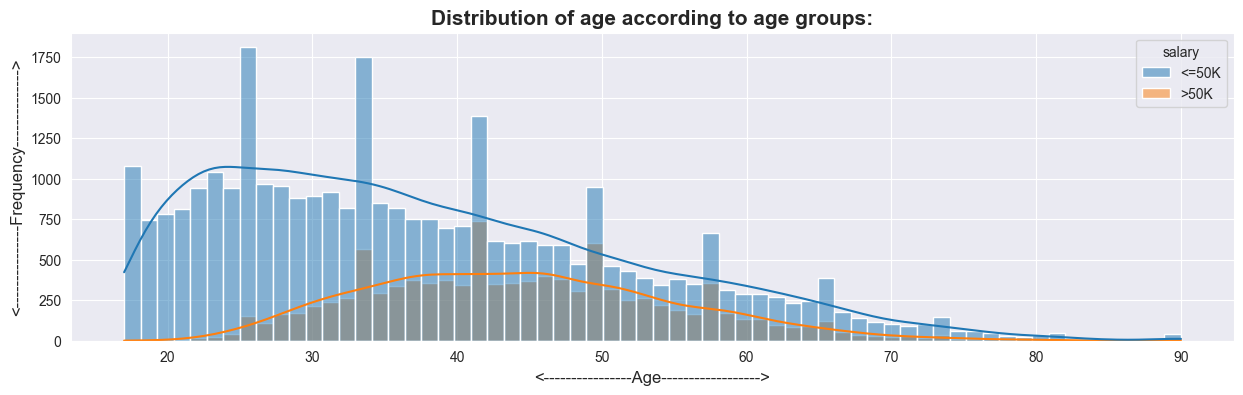

In [133]:
plt.figure(figsize=(15, 4))
sns.histplot(data= data, x= "age", hue= "salary", kde= True)
plt.title("Distribution of age according to age groups:", fontsize= 15, fontweight= 'bold')
plt.xlabel("<----------------Age------------------>", fontsize= 12)
plt.ylabel("<---------------Frequency-------------->", fontsize= 12)
plt.show()

The plot shows the distribution of age for individuals earning less than or equal to $50,000 (sky blue). The frequency is highest in the younger age groups, particularly in the 20s and early 30s. As age increases, the frequency of this group decreases significantly, indicating that younger individuals are more likely to fall into this salary category. This trend suggests that entry-level positions, which often pay less, are predominantly occupied by younger employees.

In contrast, the distribution for individuals earning more than $50,000 (orange) is more pronounced in the older age groups, particularly in the 40s and 50s. The frequency remains relatively stable until around age 40, after which it declines gradually. This indicates that higher salaries tend to be associated with more experienced workers, as they typically command larger salaries. The data suggests a clear age-related segmentation in salary, where younger individuals are more frequently found in lower-paying roles, while older individuals dominate higher-paying positions.

--------
-------
------
----

### **4. Average Age by Education Level:**

In [134]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [135]:
data["education"].unique()

array(['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th',
       'Prof-school', '7th-8th', 'Bachelors', 'Masters', 'Doctorate',
       '5th-6th', 'Assoc-voc', '9th', '12th', '1st-4th', 'Preschool'],
      dtype=object)

In [148]:
aagg= data.groupby(by= "education")["age"].describe().reset_index().sort_values(by= "mean", ascending= False)
aagg

,education,count,mean,std,min,25%,50%,75%,max
5,7th-8th,931.0,49.444683,16.430299,17.0,36.0,50.0,62.0,90.0
10,Doctorate,576.0,47.531250,11.548569,24.0,39.0,47.0,55.0,80.0
3,1st-4th,242.0,46.871901,15.169995,19.0,35.0,46.0,58.0,90.0
14,Prof-school,813.0,45.266913,12.285153,25.0,37.0,43.0,52.0,90.0
12,Masters,2499.0,44.147259,11.177830,18.0,36.0,44.0,51.0,90.0
4,5th-6th,498.0,43.642570,15.559995,17.0,30.0,43.0,55.0,84.0
13,Preschool,81.0,42.728395,15.206094,19.0,30.0,42.0,54.0,77.0
6,9th,737.0,40.956581,15.892327,17.0,28.0,39.0,54.0,90.0
11,HS-grad,12919.0,39.884047,13.884597,17.0,29.0,38.0,50.0,90.0
9,Bachelors,6967.0,39.599684,12.049201,19.0,30.0,38.0,47.0,90.0


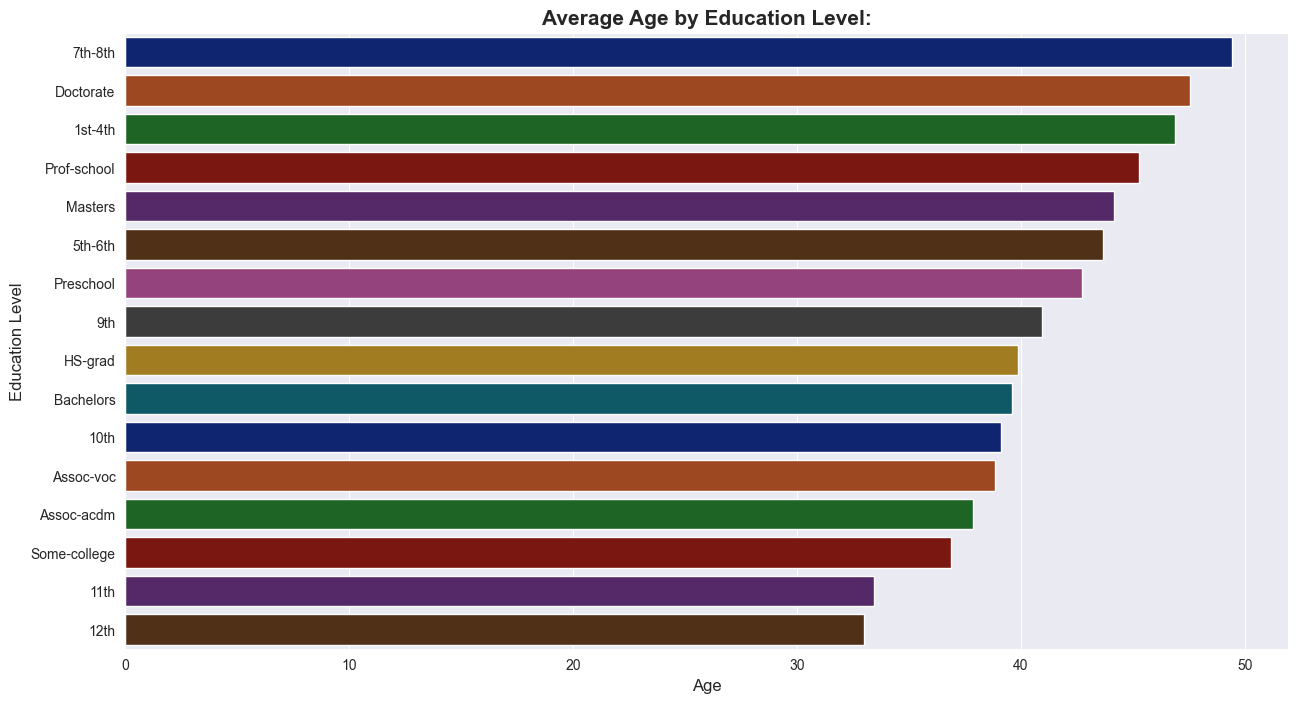

In [149]:
plt.figure(figsize=(15, 8))
sns.set_style('darkgrid')
sns.barplot(data= aagg, y= "education", x= "mean", palette= 'dark')
plt.title("Average Age by Education Level:", fontsize= 15, fontweight= 'bold')
plt.xlabel("Age", fontsize= 12)
plt.ylabel("Education Level", fontsize= 12)
plt.show()

The chart illustrates the average age associated with various education levels, showing that individuals with higher degrees, such as `Doctorate` and `Prof-school`, tend to be older, while those with lower education levels, like `Preschool` and `9th grade`, are younger. The data indicates a clear trend where higher educational attainment correlates with increased age, reflecting the time required to achieve advanced degrees.

----
----
---
----

### **5. Age vs Hours Worked per Week:**

In [150]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [152]:
data[["age", "hours-per-week"]].dtypes

age               int64
hours-per-week    int64
dtype: object

In [153]:
data["hours-per-week"].nunique()

96

First, treat hours-per-week column as categorical column insted of numeric:

In [161]:
top10= data.groupby(by= "hours-per-week")["age"].mean().sort_index(ascending= False).head(10).reset_index()
top10

,hours-per-week,age
0,99,44.007299
1,98,44.571429
2,97,30.000000
3,96,36.111111
4,95,38.500000
5,94,33.000000
6,92,40.000000
7,91,44.666667
8,90,40.928571
9,89,45.333333


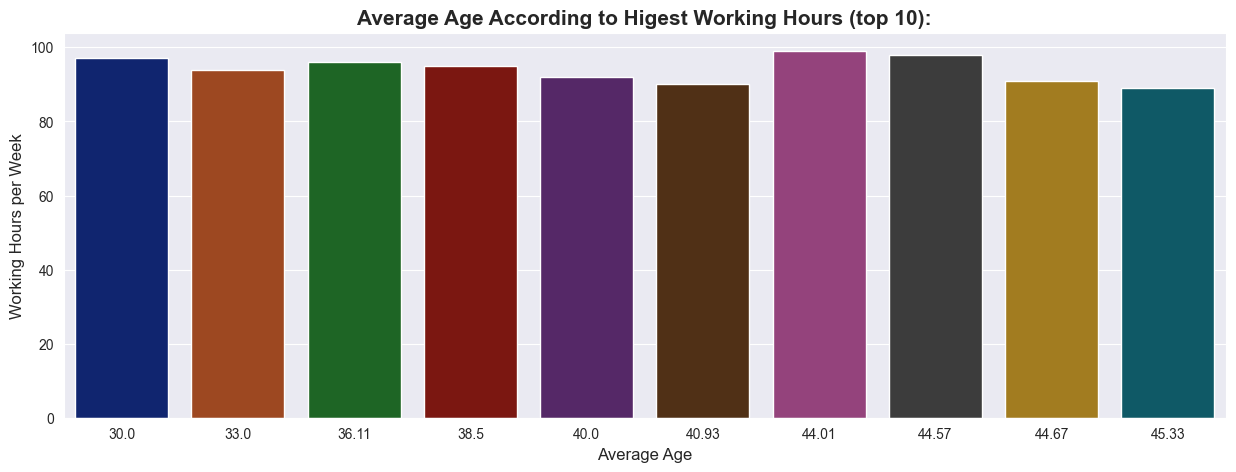

In [180]:
plt.figure(figsize=(15, 5))
sns.barplot(data= top10.round(2), y= "hours-per-week", x= "age", palette= 'dark')
plt.title("Average Age According to Higest Working Hours (top 10):", fontsize= 15, fontweight= 'bold')
plt.ylabel("Working Hours per Week", fontsize= 12)
plt.xlabel("Average Age", fontsize= 12)
plt.show()

In [163]:
last10= data.groupby(by= "hours-per-week")["age"].mean().sort_index(ascending= False).tail(10).reset_index()
last10

,hours-per-week,age
0,10,39.788512
1,9,38.000000
2,8,45.120192
3,7,46.931818
4,6,48.173913
5,5,47.542553
6,4,46.821429
7,3,53.894737
8,2,54.490566
9,1,57.111111


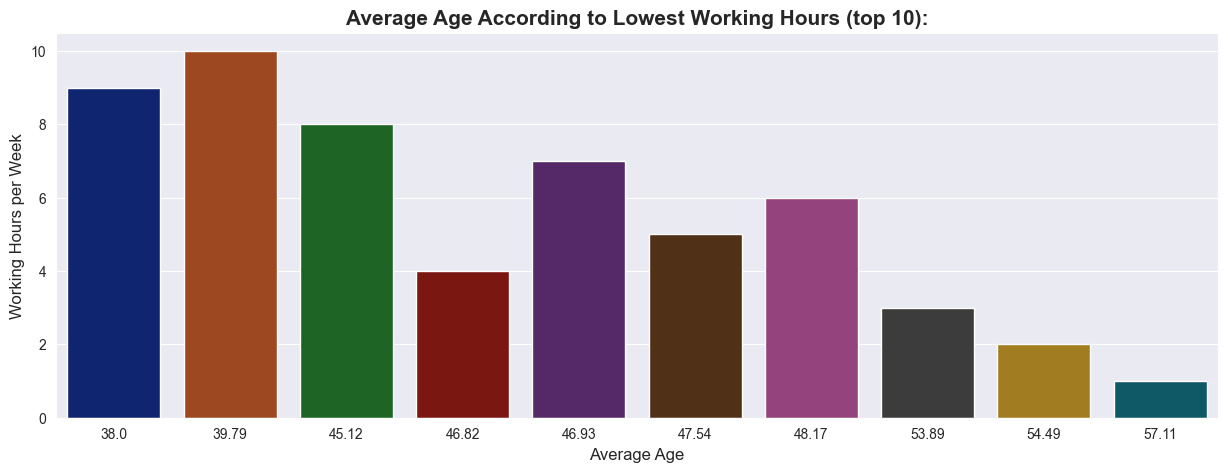

In [181]:
plt.figure(figsize=(15, 5))
sns.barplot(data= last10.round(2), y= "hours-per-week", x= "age", palette= 'dark')
plt.title("Average Age According to Lowest Working Hours (top 10):", fontsize= 15, fontweight= 'bold')
plt.ylabel("Working Hours per Week", fontsize= 12)
plt.xlabel("Average Age", fontsize= 12)
plt.show()

Second, treat both variables as numeric and then plot scatter plot:

<Axes: xlabel='age', ylabel='hours-per-week'>

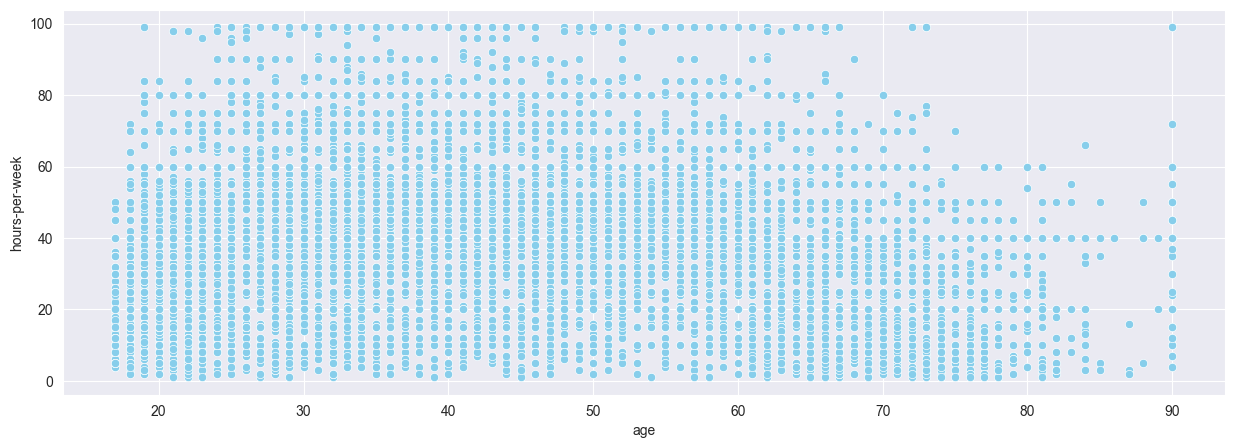

In [182]:
plt.figure(figsize=(15, 5))
sns.set_style('darkgrid')
sns.scatterplot(data= data, x= "age", y= "hours-per-week", color= 'skyblue')

Not much inference can be drawn from this scatter plot. To make a valid relationship view, lets create bins for age and the plot histograms:

In [188]:
data["age-bins"]= pd.cut(data["age"], bins= 8, labels= ["10-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80", "80-90"])

In [189]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary,age-bins
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,10-20
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,30-40
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,20-30


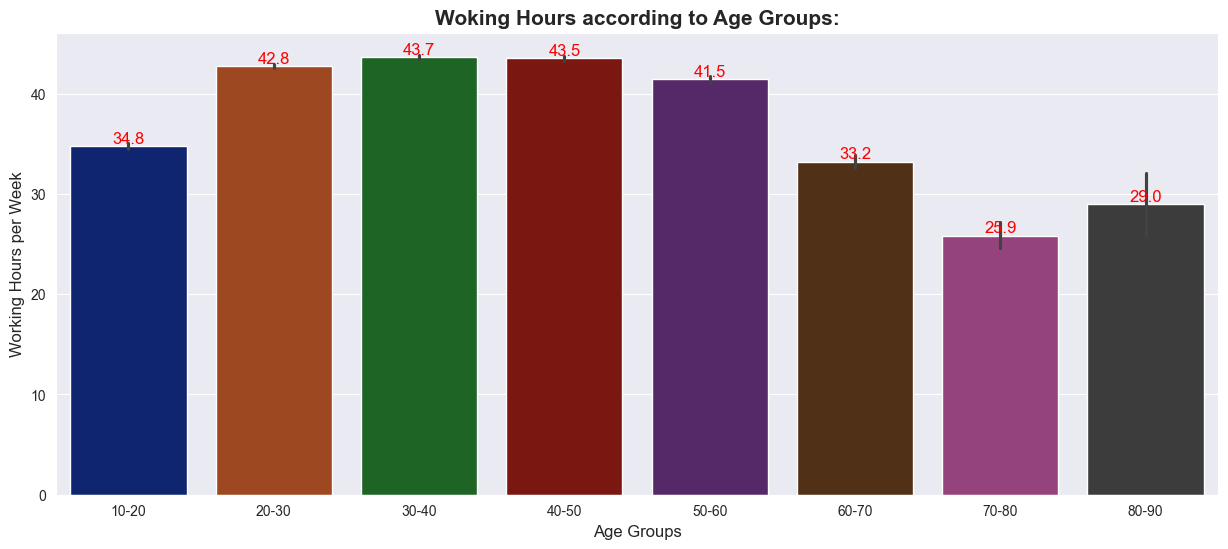

In [197]:
plt.figure(figsize= (15, 6))
ax= sns.barplot(data= data, x= "age-bins", y= "hours-per-week", palette= "dark")
plt.title("Woking Hours according to Age Groups:", fontsize= 15, fontweight= 'bold')
plt.xlabel("Age Groups", fontsize= 12)
plt.ylabel("Working Hours per Week", fontsize= 12)
for patch in ax.patches:
    ax.annotate(f'{patch.get_height():.1f}',
                (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                ha='center', va='bottom', fontsize=12, color= "red")
plt.show()

The bar chart shows the average working hours per week across different age groups. The age group 30-40 has the highest average at approximately 43.5 hours, followed closely by 40-50 with around 41.5 hours. In contrast, the 70-80 age group has the lowest average at about 20 hours. It is interesting that 80-90 age group has approximately 29 hours of average work per week which is higher then 70-80 group and is almost comparable to 60-70 years age group 33.2 hours. Overall, the data indicates that working hours tend to peak in middle age and decline in older age groups. 

---
---
---

### **6. Age and Marital Status:**

In [198]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary',
       'age-bins'],
      dtype='object')

In [199]:
data["marital-status"].unique()

array(['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced',
       'Separated', 'Married-spouse-absent', 'Married-AF-spouse'],
      dtype=object)

In [209]:
ms= data.groupby(by= "marital-status")["age"].mean().reset_index().sort_values(by= "age", ascending= False)
ms

,marital-status,age
6,Widowed,59.39
2,Married-civ-spouse,43.86
0,Divorced,43.26
3,Married-spouse-absent,40.63
5,Separated,39.78
1,Married-AF-spouse,31.95
4,Never-married,29.12


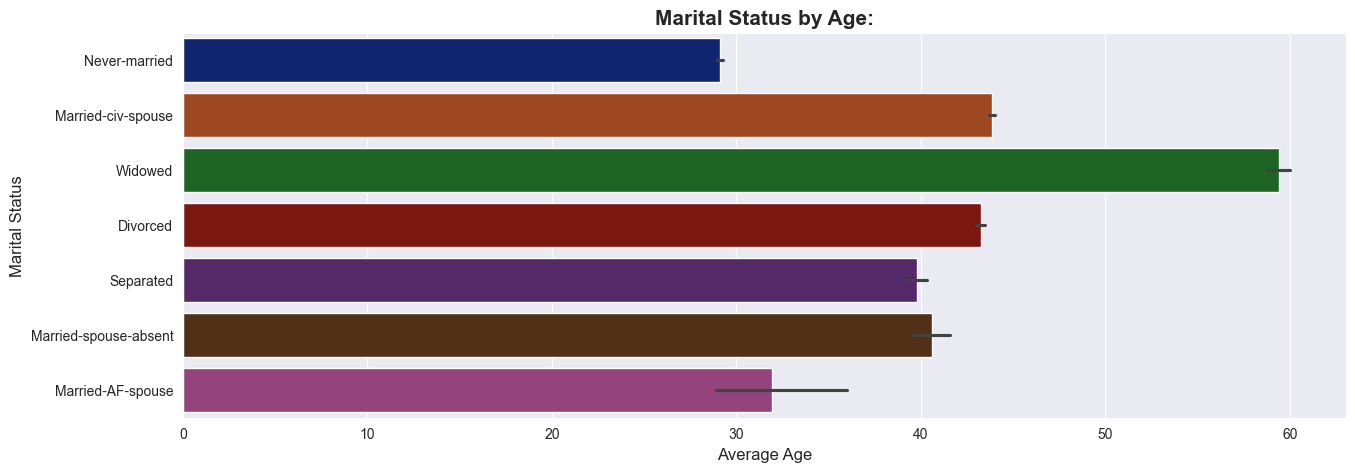

In [214]:
plt.figure(figsize=(15, 5))
sns.barplot(data= data, x= "age", y= "marital-status", palette= 'dark')
plt.title("Marital Status by Age:", fontsize= 15, fontweight= 'bold')
plt.xlabel("Average Age", fontsize= 12)
plt.ylabel("Marital Status", fontsize= 12)
plt.show()

The plot displays average ages for various marital statuses. "Widowed" individuals have the highest average age, around 60, indicating that this status typically occurs later in life. In contrast, "Never-married" individuals are younger, averaging around 30. Other statuses, such as "Married-civ-spouse" and "Divorced," fall in between, highlighting a trend where marital status varies significantly with age. Overall, the data suggests that marital status transitions occur as people age.

In [226]:
# Marital status and age groups:
dam= data.groupby(by= "marital-status")["age"].value_counts().reset_index()
dam.sample(5)

,marital-status,age,count
208,Married-spouse-absent,62,2
299,Separated,30,50
247,Never-married,44,129
152,Married-civ-spouse,84,4
20,Divorced,51,158


<Axes: xlabel='age', ylabel='count'>

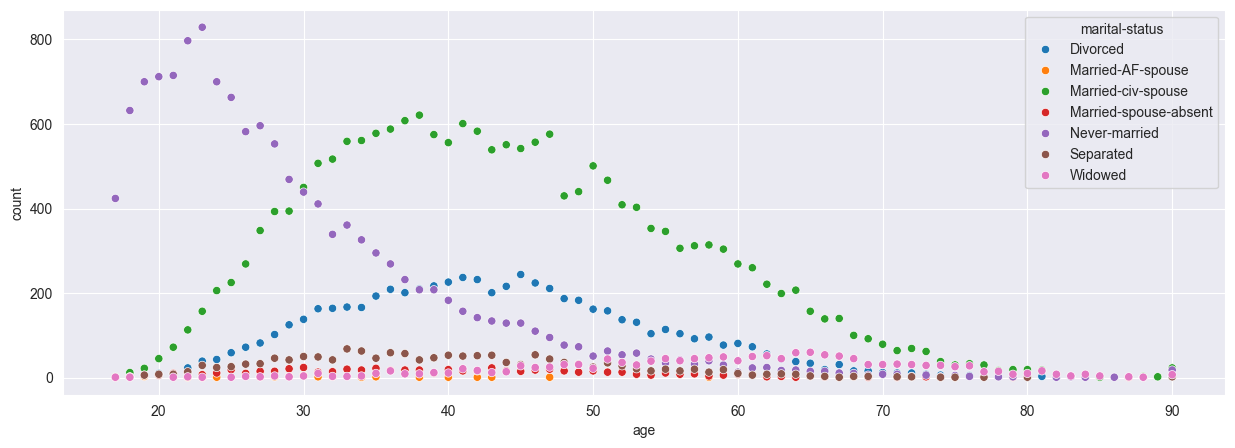

In [224]:
plt.figure(figsize=(15, 5))
sns.scatterplot(data= dam, x= "age", y= "count", hue= "marital-status")

* **`Never-married` (purple)** dominates among younger adults (peaks around age 20–25) and declines steadily with age.
* **`Married-civ-spouse` (green)** starts increasing in the 20s, peaks in the 30s–40s, and then gradually declines.
* **`Divorced` (blue)** rises from age \~30, peaks around 45–50, and then declines.
* **`Widowed` (pink)** is rare at young ages but increases steadily after age 60.
* **`Separated and Married-spouse-absent`** (brown/red) have low counts across all ages.
* **`Married-AF-spouse` (orange)** is nearly negligible, likely due to its niche category (armed forces spouse).

This plot shows expected life events: most young people are never married, most middle-aged are married, and divorce or widowhood becomes more common with age.

In [228]:
dds= data.groupby(by= "age-bins")["marital-status"].value_counts().reset_index(name= "count")

<Axes: xlabel='age-bins', ylabel='count'>

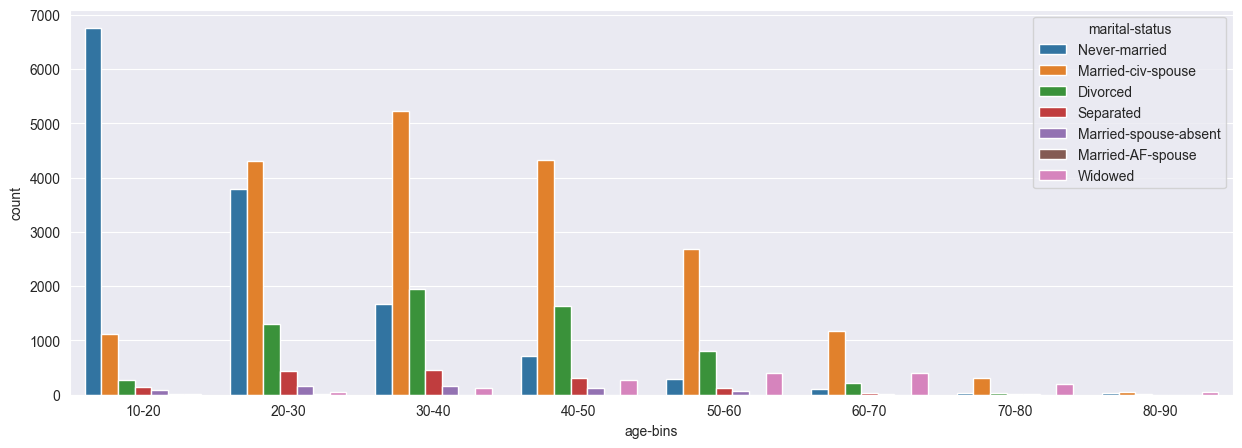

In [229]:
plt.figure(figsize=(15, 5))
sns.set_style('darkgrid')
sns.barplot(data= dds, x= "age-bins", y= "count", hue= "marital-status")

* **`10–20`**: Almost entirely **Never-married** — expected for teenagers.

* **`20–30`**: **Never-married** still common, but **Married-civ-spouse** increases significantly.

* **`30–40 & 40–50`**: **Married-civ-spouse** dominates, followed by rising **Divorced** and **Separated** cases.

* **`50–60`**: **Married-civ-spouse** still leads, but **Divorced** and **Widowed** become more visible.

* **`60+`**: Sharp decline in **Married-civ-spouse**; **Widowed** steadily increases, especially past age 60.

* **Married-AF-spouse** and **Married-spouse-absent** remain low across all ages.

Younger groups are mostly never married, middle age is dominated by marriage, and older age groups see more divorce and widowhood. The transition in marital status aligns well with typical life stages.

### **7. Age and Relationship:**

In [230]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary',
       'age-bins'],
      dtype='object')

In [231]:
data.head(2)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary,age-bins
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,10-20
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,30-40


In [232]:
data["relationship"].nunique()

6

In [233]:
data["relationship"].unique()

array(['Own-child', 'Husband', 'Not-in-family', 'Unmarried', 'Wife',
       'Other-relative'], dtype=object)

1. **`Own-child`:**
    The person is the biological or adopted child of the household head.

2. **`Husband`:**
    The person is the male spouse of the household head (usually the household head himself in traditional datasets).

3. **`Wife`:**
    The person is the female spouse of the household head.

4. **`Not-in-family`:**
    The person is living in the household but is **not related** to the head (e.g., roommate, boarder, or lodger).

5. **`Unmarried`:**
    This typically refers to someone who is **not currently married** and does not belong to a family unit in the household, often living alone.

6. **`Other-relative`:**
    The person is **related** to the head of the household but not as a spouse or child (e.g., sibling, in-law, grandparent, cousin).

In [240]:
sss= data.groupby(by= "relationship")["age"].mean().sort_values(ascending= False).reset_index()
sss

,relationship,age
0,Husband,44.56
1,Unmarried,40.46
2,Wife,40.20
3,Not-in-family,39.25
4,Other-relative,33.60
5,Own-child,25.86


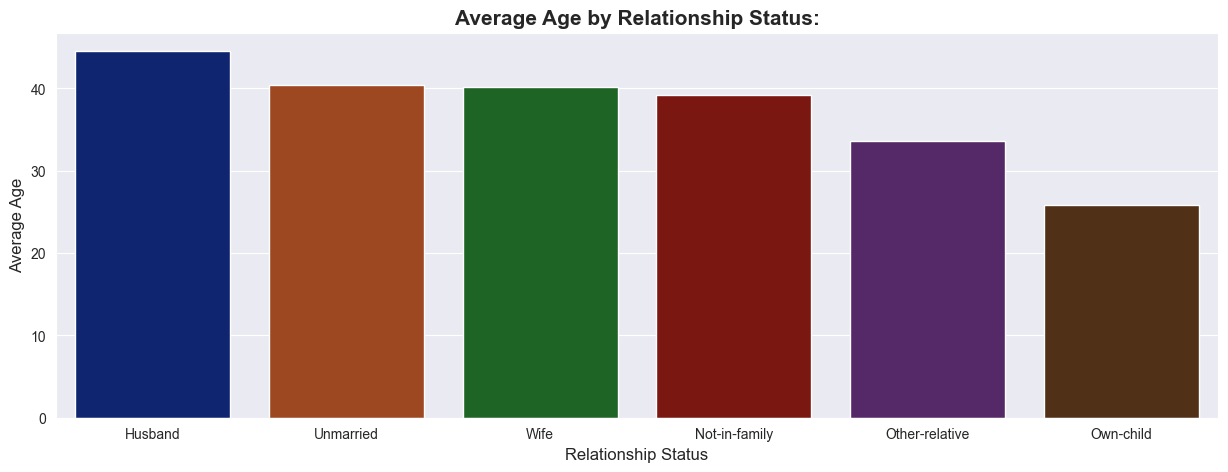

In [242]:
plt.figure(figsize=(15, 5))
sns.set_style('darkgrid')
sns.barplot(data= sss, x= "relationship", y= "age", palette= 'dark') 
plt.title("Average Age by Relationship Status:", fontsize= 15, fontweight= 'bold')
plt.xlabel("Relationship Status", fontsize= 12) 
plt.ylabel("Average Age", fontsize= 12)
plt.show()

In [245]:
sss= data.groupby(by= "relationship")["age-bins"].value_counts().reset_index()
sss.sample(5)

,relationship,age-bins,count
45,Wife,60-70,59
14,Not-in-family,70-80,224
5,Husband,10-20,799
34,Unmarried,40-50,1007
15,Not-in-family,80-90,65


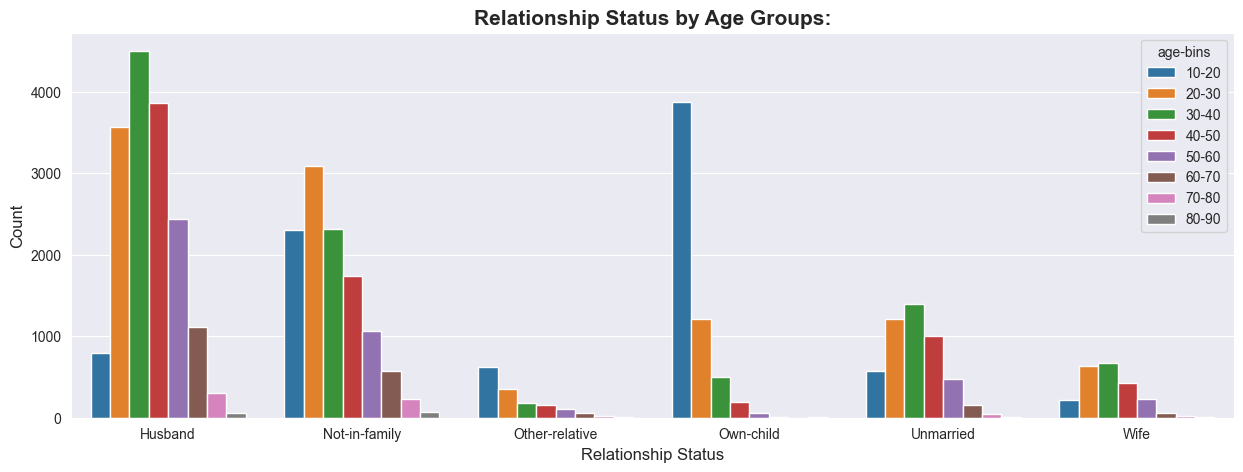

In [247]:
plt.figure(figsize=(15, 5))
sns.set_style('darkgrid')
sns.barplot(data= sss, x= "relationship", y= "count", hue= "age-bins")
plt.title("Relationship Status by Age Groups:", fontsize= 15, fontweight= 'bold')
plt.xlabel("Relationship Status", fontsize= 12)
plt.ylabel("Count", fontsize= 12)
plt.show()

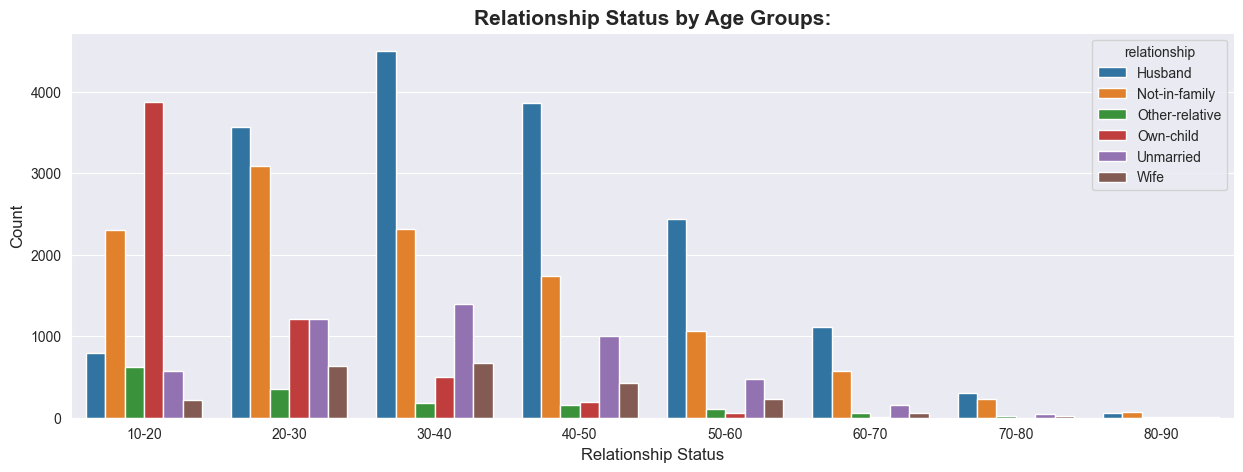

In [ ]:
plt.figure(figsize=(15, 5))
sns.set_style('darkgrid')
sns.barplot(data= sss, hue= "relationship", y= "count", x= "age-bins")
plt.title("Relationship Status by Age Groups:", fontsize= 15, fontweight= 'bold')
plt.xlabel("Age groups", fontsize= 12)
plt.ylabel("Count", fontsize= 12)
plt.show()

In [286]:
sss= data.groupby(by= "relationship")["age"].value_counts().reset_index()
sss.sample(5)

,relationship,age,count
132,Not-in-family,77,21
359,Wife,53,36
262,Unmarried,34,162
35,Husband,26,212
375,Wife,20,6


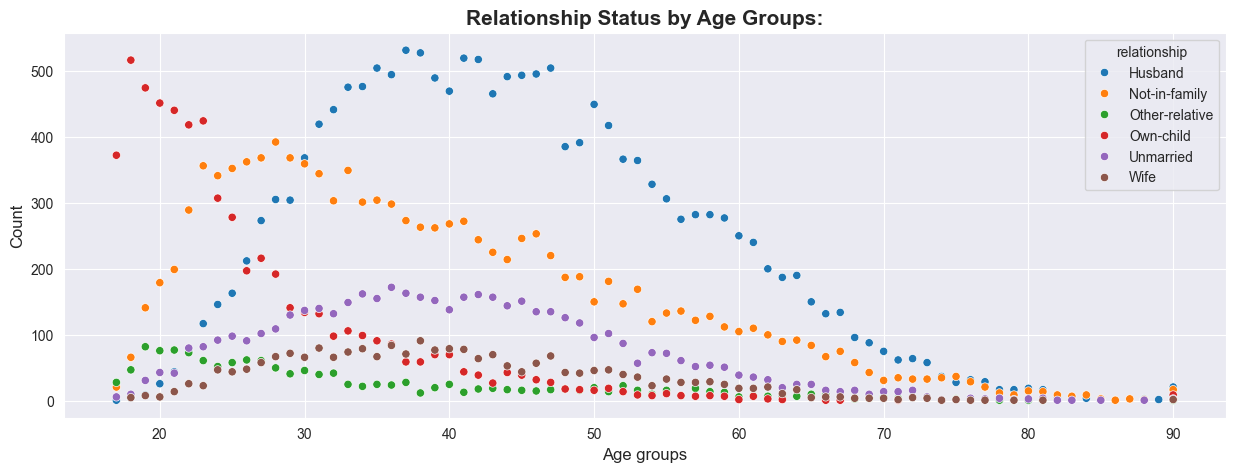

In [ ]:
plt.figure(figsize=(15, 5))
sns.set_style('darkgrid')
sns.scatterplot(data= sss, hue= "relationship", y= "count", x= "age")
plt.title("Relationship Status by Age Groups:", fontsize= 15, fontweight= 'bold')
plt.xlabel("Age", fontsize= 12)
plt.ylabel("Count", fontsize= 12)
plt.show()

### **8. Occupation and Age:**

In [250]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary',
       'age-bins'],
      dtype='object')

In [251]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary,age-bins
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,10-20
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,30-40
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,20-30


In [252]:
data["occupation"].nunique()

15

In [253]:
data["occupation"].unique()

array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv',
       'Others', 'Other-service', 'Prof-specialty', 'Craft-repair',
       'Adm-clerical', 'Exec-managerial', 'Tech-support', 'Sales',
       'Priv-house-serv', 'Transport-moving', 'Handlers-cleaners',
       'Armed-Forces'], dtype=object)

Mean age of workers in each of the occupation groups:

In [295]:
occ= data.groupby(by= "occupation")["age"].mean().reset_index(name="Mean Age")
occ

,occupation,Mean Age
0,Adm-clerical,38.25
1,Armed-Forces,31.47
2,Craft-repair,39.41
3,Exec-managerial,42.61
4,Farming-fishing,41.59
5,Handlers-cleaners,33.74
6,Machine-op-inspct,38.36
7,Other-service,36.48
8,Others,42.33
9,Priv-house-serv,43.55


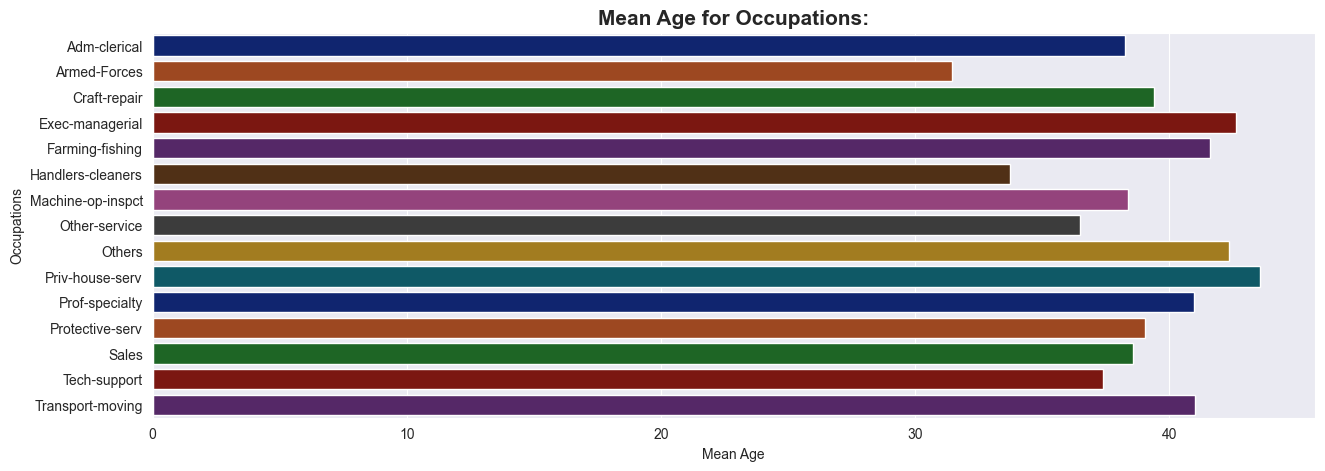

In [298]:
plt.figure(figsize=(15, 5))
sns.barplot(data= occ, x= "Mean Age", y= "occupation", palette="dark")
plt.title("Mean Age for Occupations:", fontsize= 15, fontweight= 'bold')
plt.xlabel("Mean Age")
plt.ylabel("Occupations")
plt.show()

**Number of People in different age groups according to their occupation:**

In [299]:
sss= data.groupby(by= "occupation")["age-bins"].value_counts().reset_index()
sss

,occupation,age-bins,count
0,Adm-clerical,10-20,1141
1,Adm-clerical,20-30,1123
2,Adm-clerical,30-40,1043
3,Adm-clerical,40-50,786
4,Adm-clerical,50-60,469
...,...,...,...
115,Transport-moving,10-20,289
116,Transport-moving,50-60,284
117,Transport-moving,60-70,92
118,Transport-moving,70-80,14


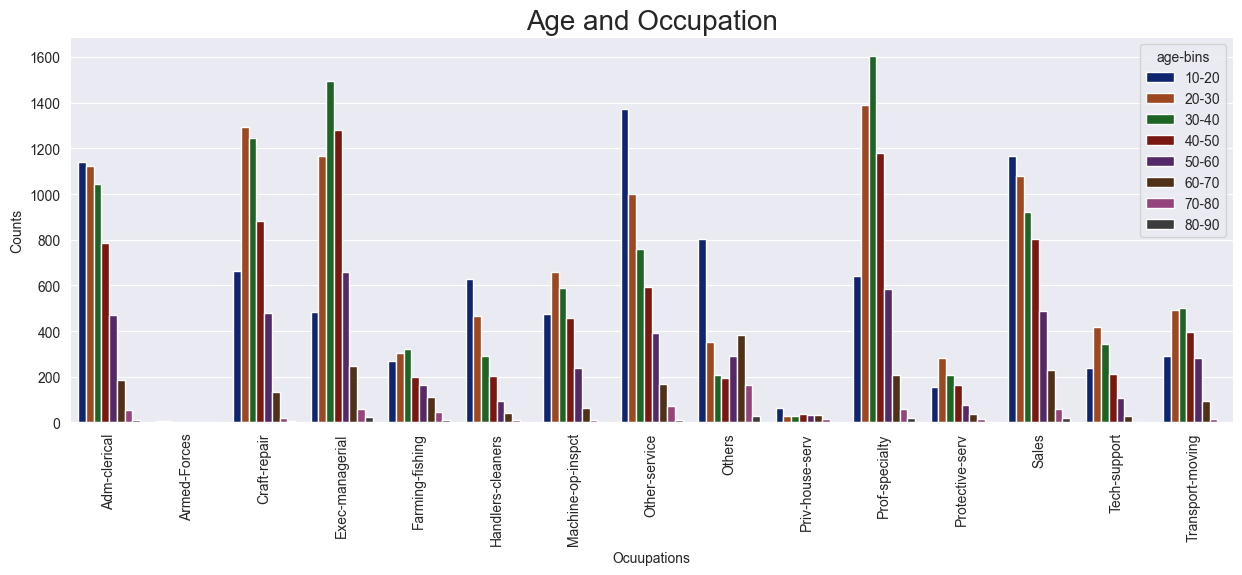

In [ ]:
plt.figure(figsize=(15, 5))
sns.barplot(data= sss, x= "occupation", y= "count", hue= "age-bins", palette= "dark")
plt.xticks(rotation= 90)
plt.xlabel("Ocuupations")
plt.ylabel("Counts")
plt.title("Age and Occupation:", fontsize= 20, fontweight= 20)
plt.show()

Because dataset have very few records for Armed-Forces, in above plot, the plot shows almost nothing in that section. 

In [285]:
sss[sss["occupation"]== "Armed-Forces"]

,occupation,age-bins,count
8,Armed-Forces,10-20,6
9,Armed-Forces,20-30,5
10,Armed-Forces,30-40,2
11,Armed-Forces,40-50,2
12,Armed-Forces,50-60,0
13,Armed-Forces,60-70,0
14,Armed-Forces,70-80,0
15,Armed-Forces,80-90,0


**Age distribution of people according to their occupation:**

In [288]:
sss= data.groupby(by= "occupation")["age"].value_counts().reset_index()
sss

,occupation,age,count
0,Adm-clerical,23,156
1,Adm-clerical,31,146
2,Adm-clerical,26,143
3,Adm-clerical,27,142
4,Adm-clerical,30,142
...,...,...,...
935,Transport-moving,78,2
936,Transport-moving,81,2
937,Transport-moving,90,2
938,Transport-moving,72,1


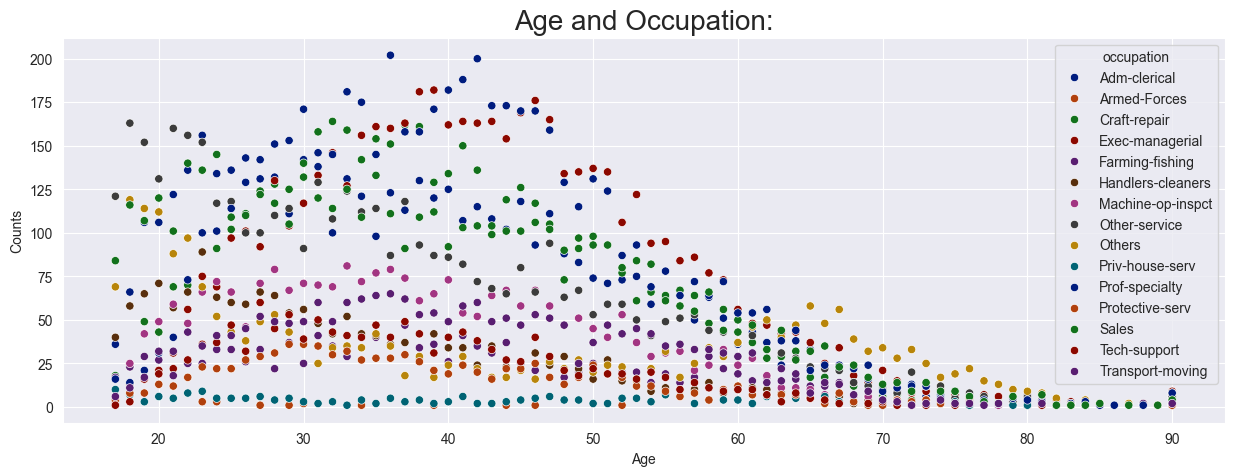

In [291]:
plt.figure(figsize=(15, 5))
sns.scatterplot(data= sss, x= "age", y= "count", hue= "occupation", palette= "dark")
plt.xlabel("Age")
plt.ylabel("Counts")
plt.title("Age and Occupation:", fontsize= 20, fontweight= 20)
plt.show()